In [31]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
import pandas as pd
from reco_plots import MovieRecommender
from embeddings.word2vec import Word2VecEmbedder
from embeddings.bert import BERTEmbedder

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
from embeddings.bow import BoWEmbedder

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [ ]:
# --- Config ---
POSTERS_BASE_PATH = Path.cwd().parent.parent / 'sorted_movie_posters_paligema'
CSV_PATH = "data/movie_plots.csv"
QUERY = "A secret agent is sent on a mission to prevent a criminal organisation to rule the world. The hero will be helped by high tech gadgets and several people in the field. The main character will also have to deal with his own personal issues."
TOP_K = 5

# --- Chargement ---
df = pd.read_csv(CSV_PATH)
print(f"Dataset chargé : {len(df)} films\n")


def display_recommendations(results: pd.DataFrame, method_name: str):
    """Affiche les résultats avec les posters sous forme de grille matplotlib."""
    fig, axes = plt.subplots(1, len(results), figsize=(4 * len(results), 6))
    fig.suptitle(f"Recommandations — {method_name}", fontsize=14, fontweight='bold')

    if len(results) == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, results.iterrows()):
        img_path = POSTERS_BASE_PATH / row['movie_poster_path'].lstrip('/')

        if img_path.exists():
            img = mpimg.imread(str(img_path))
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, 'Image\nnon trouvée',
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_facecolor('#eeeeee')

        ax.axis('off')
        score = f"{row['similarity_score']:.3f}"
        category = row.get('movie_category', '')
        # Titre court pour l'affichage
        plot_preview = row['movie_plot'][:60] + '...' if len(row['movie_plot']) > 60 else row['movie_plot']
        ax.set_title(f"{category}\nscore: {score}", fontsize=9)
        ax.set_xlabel(plot_preview, fontsize=7, wrap=True)

    plt.tight_layout()
    plt.show()
  


Dataset chargé : 5385 films



MÉTHODE : TF-IDF / Bag of Words
Index construit et sauvegardé : (5385, 10000)
movie_category  similarity_score
        comedy          0.190215
        comedy          0.148065
        comedy          0.131241
      thriller          0.126707
        horror          0.124395


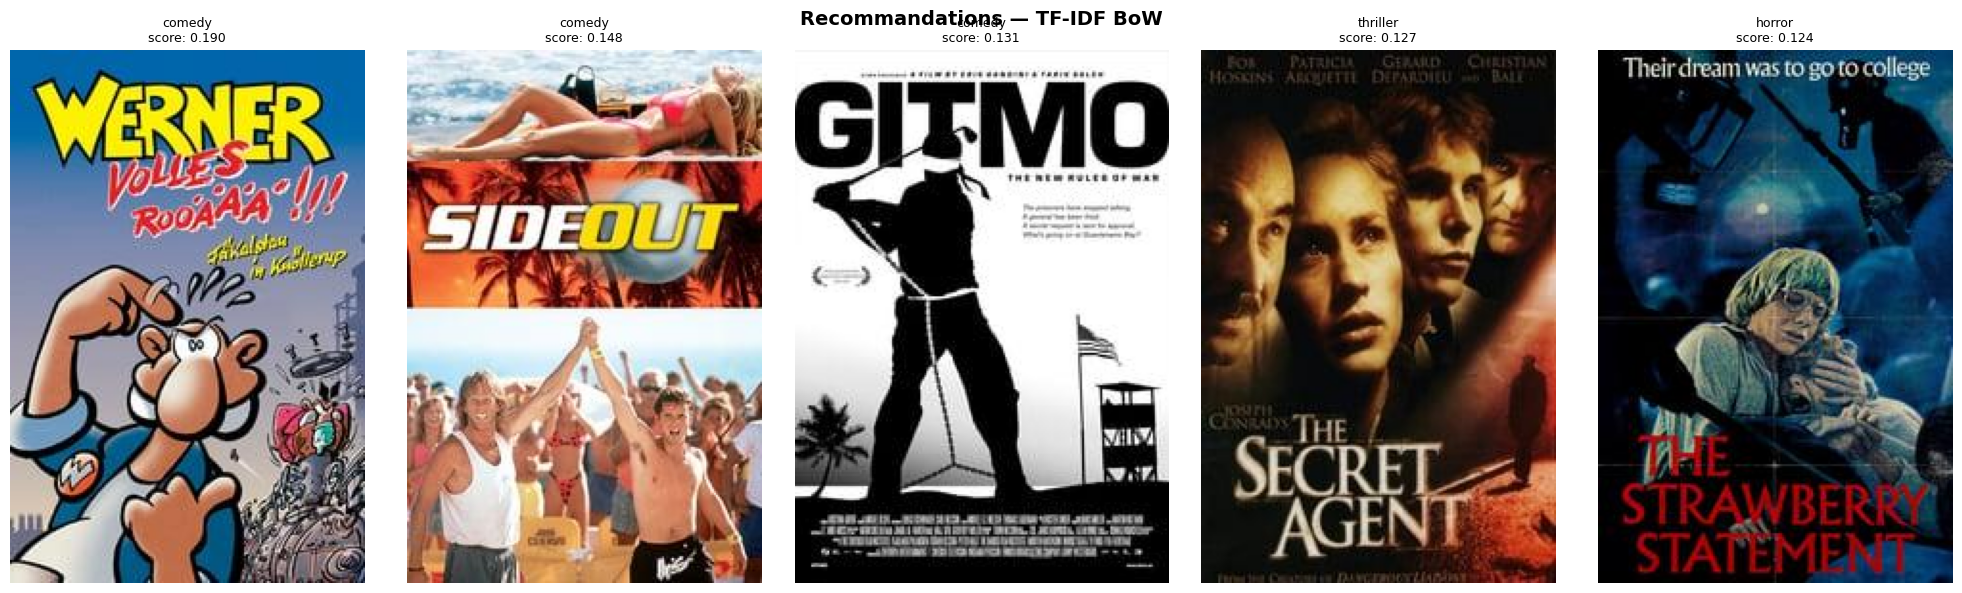

In [52]:

# =========================================================
# TEST 1 : BoW
# =========================================================
print("=" * 50)
print("MÉTHODE : TF-IDF / Bag of Words")
print("=" * 50)
bow = BoWEmbedder()
rec_bow = MovieRecommender(bow, df, model_name="bow")
rec_bow.load_or_build_index()
results_bow = rec_bow.recommend(QUERY, TOP_K)
print(results_bow[['movie_category', 'similarity_score']].to_string(index=False))
display_recommendations(results_bow, "TF-IDF BoW")



MÉTHODE : Word2Vec
Chargement du modèle pré-entraîné glove-wiki-gigaword-100...
Index chargé : (5385, 100)
movie_category  similarity_score
        comedy          0.966799
        action          0.965456
        action          0.964548
        action          0.964249
        action          0.964089


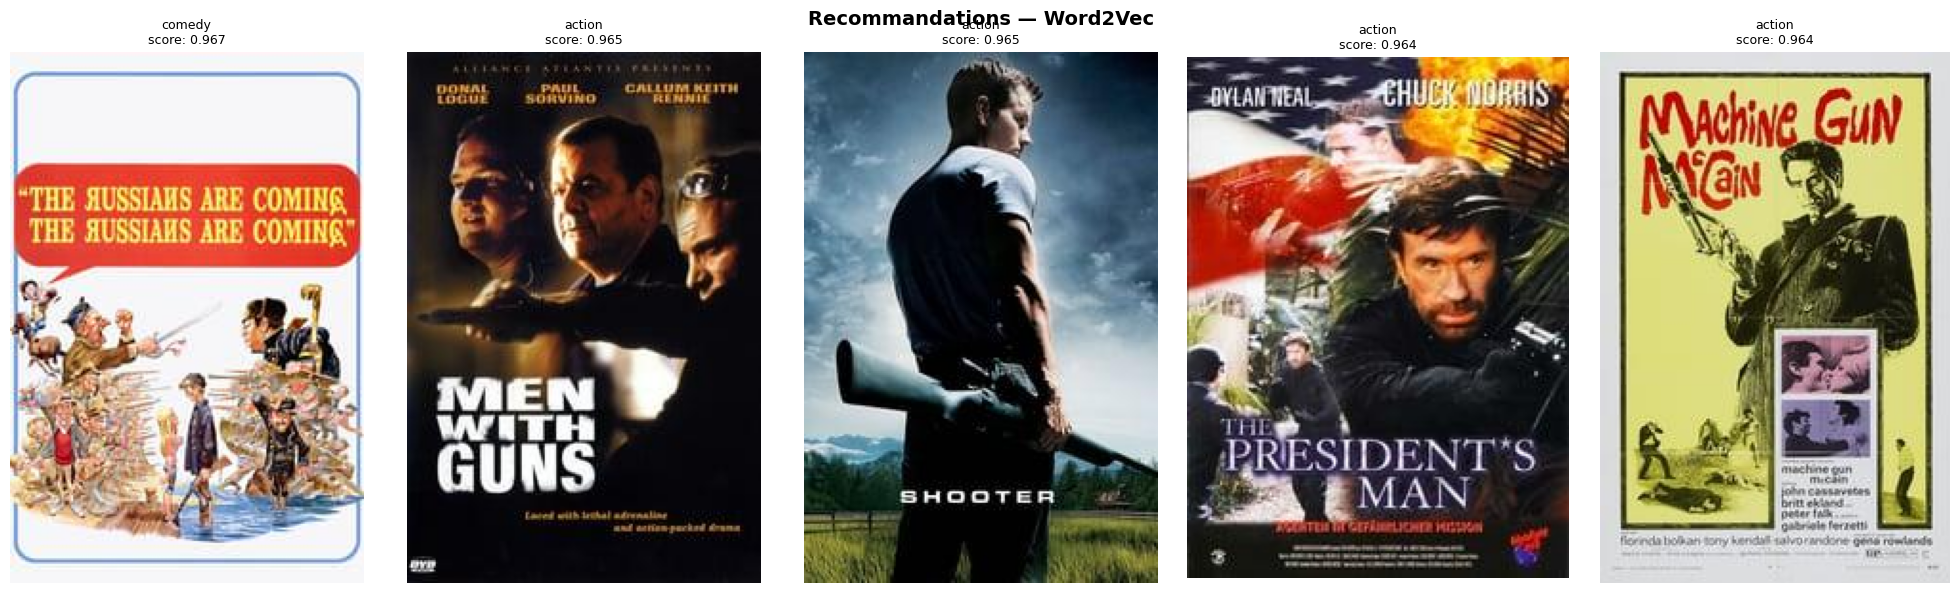

In [48]:

# =========================================================
# TEST 2 : Word2Vec
# =========================================================
print("\n" + "=" * 50)
print("MÉTHODE : Word2Vec")
print("=" * 50)
w2v = Word2VecEmbedder()
rec_w2v = MovieRecommender(w2v, df, model_name="w2v")
rec_w2v.load_or_build_index()
results_w2v = rec_w2v.recommend(QUERY, TOP_K)
print(results_w2v[['movie_category', 'similarity_score']].to_string(index=False))
display_recommendations(results_w2v, "Word2Vec")



MÉTHODE : BERT
Chargement du modèle Sentence-Transformers : multi-qa-MiniLM-L6-cos-v1


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4372.38it/s]
BertModel LOAD REPORT from: sentence-transformers/multi-qa-MiniLM-L6-cos-v1
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Index chargé : (5385, 384)
movie_category  similarity_score
      thriller          0.745139
        action          0.507565
      thriller          0.505788
        action          0.504231
      thriller          0.504128


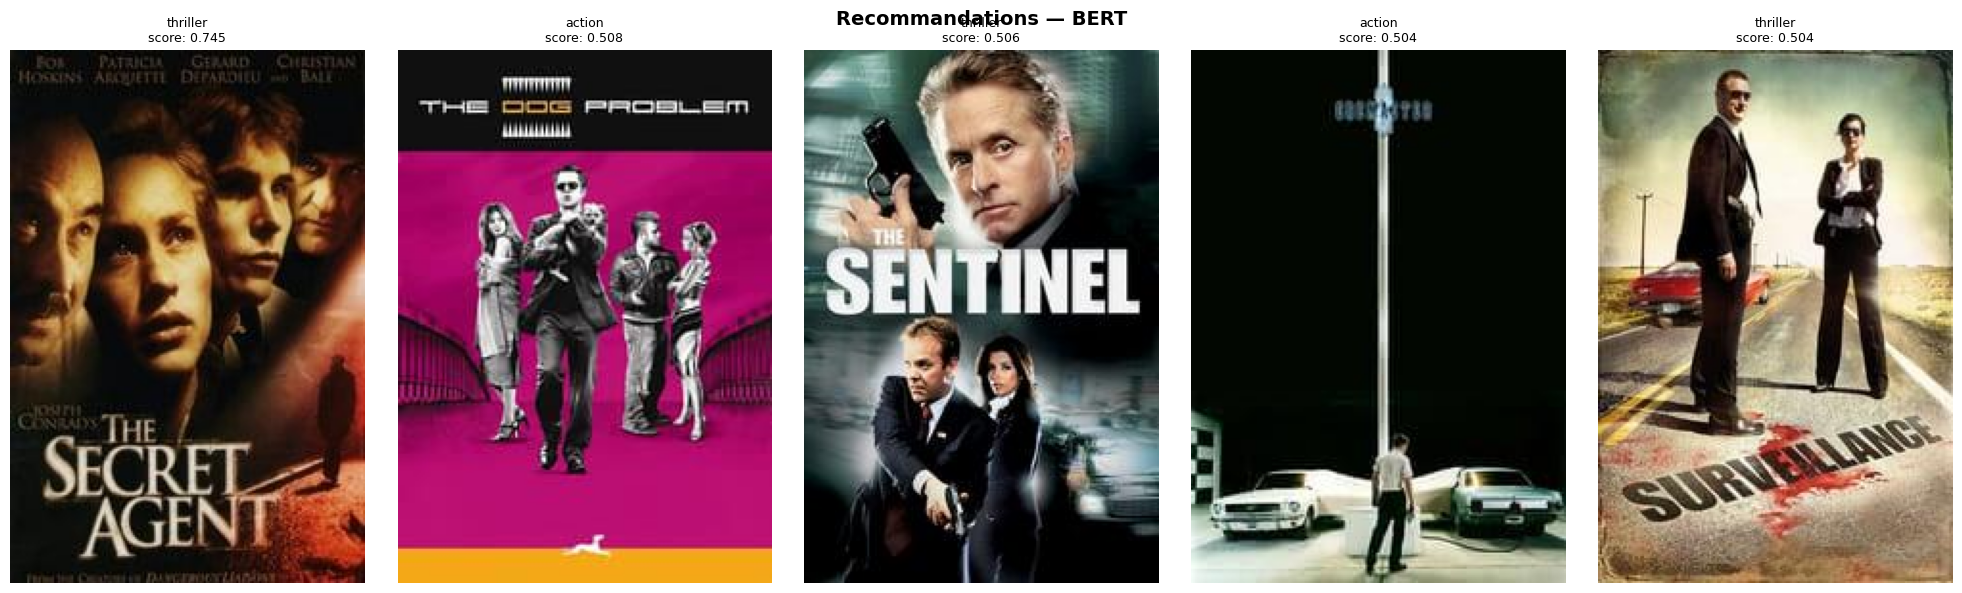

In [49]:

# =========================================================
# TEST 3 : BERT
# =========================================================
print("\n" + "=" * 50)
print("MÉTHODE : BERT")
print("=" * 50)
bert = BERTEmbedder()
rec_bert = MovieRecommender(bert, df, model_name="bert")
rec_bert.load_or_build_index()
results_bert = rec_bert.recommend(QUERY, TOP_K)
print(results_bert[['movie_category', 'similarity_score']].to_string(index=False))
display_recommendations(results_bert, "BERT")